# Practical L7

<div class="page-subtitle">
The Climate Crisis Assessment
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/09_L07_vector-data/09_practical_L7.ipynb)

---

```{admonition} A Note on Challenges
:class: important

**This is a real-world challenge.** This practical represents a step up in difficulty because it accurately reflects the actual, messy workflow of an environmental data scientist. You will be dealing with live government servers and complex multi-step spatial operations. 

Do not be discouraged if your code throws errors—debugging is part of the process! Read the error messages carefully, make heavy use of the **Hints** provided in each task, and take your time exploring the linked documentation to build your solutions.
```

## Learning objectives

After completing this practical, you will be able to:

  * transform raw coordinate data from live APIs into metric-projected `GeoDataFrames`.
  * automate spatial data workflows by combining Python loops with live environmental data.
  * calculate and extract long-term linear trends across multiple distinct timeframes (10-year, 30-year, and all-time).
  * perform point-in-polygon loops to aggregate local point data (weather stations) into regional administrative boundaries (cantons).
  * design thematic maps to effectively communicate regional climate trends across different timeframes.

---

## Practical storyline

You are a climate data scientist tasked with creating a national assessment of warming trends for the Swiss government. Instead of relying on a single historic file, you need to tap directly into the live Automatic Weather Station (AWS) network maintained by MeteoSwiss.

Your goal is to download the historical metadata for all stations, isolate the ones you need, dynamically download their daily weather records, calculate exactly how fast their temperatures are rising across different time periods, and finally, visualize these warming trends on a map of Switzerland.

---

```{admonition} Download the Datasets
:class: note
Please download this file to your local working directory for this lesson:
* [swissBoundaries3D_switzerland.gpkg](https://gitlab.com/HendrikWulf/sds210/-/blob/main/L07/data/swissBoundaries3D_switzerland.gpkg)
* [swissBoundaries3D_cantons.gpkg](https://gitlab.com/HendrikWulf/sds210/-/blob/main/L07/data/swissBoundaries3D_cantons.gpkg)
* [kloten_test_data.csv](https://gitlab.com/HendrikWulf/sds210/-/blob/main/L07/data/kloten_test_data.csv)
```

---

## Part 1 – The Metadata Intake

First, we need to know where the weather stations are and what their 3-letter API codes are. MeteoSwiss provides a live metadata file containing this information.

Before writing any code, take a moment to download the file from Task 1 and open it in a text editor or spreadsheet program to familiarize yourself with its structure and columns.

### Tasks

1.  **Download Metadata:** Use [`pd.read_csv()`](https://www.google.com/search?q=%5Bhttps://pandas.pydata.org/docs/reference/api/pandas.read_csv.html%5D\(https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html\)) to download the live metadata file directly from this URL: `https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/ogd-smn_meta_stations.csv`. Save it as `stations_meta`.
      * *Hint:* Set `sep=';'` as they use semicolons, and add `encoding="latin1"` to prevent errors when reading French and German accents\!
2.  **Filter for Long-Term Data:** The network contains hundreds of stations. We only want those collecting data since at least **January 1st, 1981**.
      * *Hint:* First, convert the `"station_data_since"` column to datetime using `pd.to_datetime(..., format="%d.%m.%Y")`. Then filter for `<= "1981-01-01"` and append `.copy()`.
3.  **Create and Project the GeoDataFrame:** Convert the filtered `stations_meta` into a GeoDataFrame called `stations_gdf`.
      * *Hint:* To practice coordinate transformations, use [`gpd.points_from_xy()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.points_from_xy.html) with the global longitude and latitude columns (`station_coordinates_wgs84_lon` for X, and `station_coordinates_wgs84_lat` for Y). Set the initial CRS to `EPSG:4326` (degrees), and then immediately project the GeoDataFrame to the Swiss metric grid (`EPSG:2056`) using [`.to_crs()`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.to_crs.html#geopandas.GeoDataFrame.to_crs).
4.  **Verify the Result:** Print out how many stations you have successfully found by checking the length of your new GeoDataFrame.
      * *Hint:* Do not confuse the standard Python `len(stations_gdf)` (which counts the number of rows) with the GeoPandas `stations_gdf.length` attribute (which calculates the physical geometric length of spatial features)

In [1]:
import pandas as pd
import geopandas as gpd

# Write your code here

# 1. Download metadata (using semicolon separator AND latin1 encoding)

stations_meta = pd.read_csv("https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/ogd-smn_meta_stations.csv",
                            sep=";",
                            encoding="latin1")

stations_meta["station_data_since"] = pd.to_datetime(
    stations_meta["station_data_since"], format="%d.%m.%Y"
)

stations_meta = stations_meta[
    stations_meta["station_data_since"]<= "1981-01-01"
].copy()

stations_gdf = gpd.GeoDataFrame(
    stations_meta,
    geometry=gpd.points_from_xy(
        stations_meta["station_coordinates_wgs84_lon"],
        stations_meta["station_coordinates_wgs84_lat"]
        ),
        crs = "EPSG:4326"
)

stations_gdf = stations_gdf.to_crs("EPSG:2056")

# 4. Verify the result
print(f"Found {len(stations_gdf)} long-term climate stations.")


Found 120 long-term climate stations.


---

## Part 2 – The Trend Engine (Function)

In the [previous practical](https://hendrikwulf.github.io/sds210-jb/book/l06-data-frames/practical-l6/), we calculated the linear warming trend for a single station. Because we are about to do this for *many* stations across three different time periods, we need to wrap that logic into a reusable Python function.

### Tasks

1.  **Define the Function:** Create a function called `calculate_trend(df, start_date, end_date="2025-12-31")`. We set a default `end_date` to ensure we strictly calculate trends over *full calendar years* (avoiding incomplete data from the current year).
2.  **Slice by Time:** Inside the function, slice the provided `df` using `.loc[start_date:end_date]`. *(Hint: Pandas [`.loc`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) string slicing is inclusive, so "2025-12-31" perfectly captures the full final year!)*
3.  **Resample:** [Resample](https://pandas.pydata.org/docs/reference/api/pandas.Series.resample.html#pandas.Series.resample) the sliced data's `tre200d0` column (MeteoSwiss code for Daily Mean Temperature) to annual (`"YE"`) averages using `.mean()`. Chain [`.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.dropna.html#pandas.Series.dropna) to the end.
4.  **Safety Check:** If a station has massive data gaps, the math will fail. Add an `if` statement: if the length of your resampled annual data is `< 5` years, immediately `return np.nan`.
5.  **Calculate Slope:** Create a time array using `years_passed = np.arange(len(annual_temps))` ([docu arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange)). Then, use `numpy.polyfit(years_passed, annual_temps, 1)` to calculate the slope ([docu polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)).
6.  **Return:** The slope from `polyfit` is degrees per year. Return the calculated slope multiplied by **10** to give the trend per **decade** (the standard metric for climate reporting).
7.  **Test Your Engine!** We cannot expect a complex function to work perfectly on the first try. Call your newly built function using the `kloten_test_data.csv` dataset provided above! Try passing different `start_date` strings (e.g. `"2016-01-01"`, `"1996-01-01"`) and print the results to ensure your code successfully generates a warming trend. If you get stuck, review your Linear Trend code from the [previous practical](https://hendrikwulf.github.io/sds210-jb/book/l06-data-frames/practical-l6/).

In [2]:
import numpy as np
import pandas as pd

# Write your code here

def calculate_trend(df, start_date, end_date="2025-12-31"):
    #df["DATE"] = pd.to_datetime(df["DATE"])
    #df = df.set_index("DATE")
    df = df.loc[start_date:end_date]
    annual_temps = df["tre200d0"].resample("YE").mean().dropna()
    if len(annual_temps) < 5:
        return np.nan
    years_passed = np.arange(len(annual_temps))
    coefficients = np.polyfit(years_passed, annual_temps.values, 1)
    slope = coefficients[0]
    slope_10 = slope*10
    return slope_10

df = pd.read_csv("kloten_test_data.csv")
calculate_trend(df, "2020-01-01")

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

---

## Part 3 – The API Download Loop

This is where it all comes together. We will loop through the `station_abbr` codes in our metadata, ping the MeteoSwiss API to download the historic weather file for each station, clean the data, and run our trend engine for three different timeframes.

*(Warning: Downloading 120 files takes a moment. For testing your loop, you might want to slice `stations_gdf.head(3)` first before running the full set!)*

### Tasks

1.  **Initialize Lists:** Import `tqdm` from [`tqdm.auto`](https://tqdm.github.io/docs/shortcuts/#tqdmauto). Create three empty lists to store your results: `trends_10yr`, `trends_30yr`, and `trends_all`.
2.  **The Progress Loop:** Write a `for` loop that iterates over the `station_abbr` column in `stations_gdf`. Wrap the iterable in `tqdm()` to generate a live progress bar.
3.  **Construct URL:** Inside the loop, construct the API URL using an f-string. The URL structure is: `https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/[ABBR]/ogd-smn_[ABBR]_d_historical.csv` *(replace [ABBR] with the lowercase station abbreviation `abbr.lower()`).*
4.  **Download and Clean:** Download the CSV to a `daily_df` dataframe using `pd.read_csv()`. 
    * *Hint:* Load it with `sep=";"`, `index_col="reference_timestamp"`, and `low_memory=False`.
    * Force the index to datetime using `pd.to_datetime(daily_df.index, format="%d.%m.%Y %H:%M")`.
    * **Crucial:** Run `daily_df = daily_df.sort_index()` so Pandas allows time-slicing!
5.  **Calculate:** Pass the cleaned `daily_df` into your `calculate_trend()` function three times with these start dates: `"2016-01-01"`, `"1996-01-01"`, and `"1981-01-01"`. Append the results to your three respective lists.
6.  **Assign Results:** After the loop finishes entirely, assign those three lists back into your `stations_gdf` as new columns. Print the mean of the all-time trend to verify your results!

In [3]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm  # The standard progress bar library!

# Write your code here
trends_10yr = []
trends_30yr = []
trends_all = []
url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/[ABBR]/ogd-smn_[ABBR]_d_historical.csv"
date_1 = "2016-01-01"
date_2 = "1996-01-01"
date_3 = "1981-01-01"
subset = stations_gdf.head(3).copy()

for abbr in tqdm(stations_gdf["station_abbr"]):
    try:
        # Build URL correctly
        new_url = url.replace("[ABBR]", abbr.lower())

        # Load data
        daily_df = pd.read_csv(
            new_url,
            sep=";",
            index_col="reference_timestamp",
            low_memory=False
        )

        # Convert index to datetime (IMPORTANT)
        daily_df.index = pd.to_datetime(
            daily_df.index,
            format="%d.%m.%Y %H:%M",
            errors="coerce"
        )

        # Drop invalid dates if any
        #daily_df = daily_df.dropna(subset=[daily_df.index.name])

        # Sort index
        daily_df = daily_df.sort_index()

        # Compute trends
        trends_10yr.append(calculate_trend(daily_df, date_1))
        trends_30yr.append(calculate_trend(daily_df, date_2))
        trends_all.append(calculate_trend(daily_df, date_3))

    except Exception as e:
        # If anything fails, append NaN
        print(f"Error for {abbr}: {e}")
        trends_10yr.append(float("nan"))
        trends_30yr.append(float("nan"))
        trends_all.append(float("nan"))

# Assign results back
stations_gdf["trends_10yr"] = trends_10yr
stations_gdf["trends_30yr"] = trends_30yr
stations_gdf["trends_all"] = trends_all

print(stations_gdf["trends_10yr"], stations_gdf["trends_30yr"], stations_gdf["trends_all"])

  0%|          | 0/120 [00:00<?, ?it/s]

0      1.347628
2      1.123455
3      0.730415
4      0.865119
5      1.240443
         ...   
153    1.015228
154    0.775636
155    1.338650
156    1.000117
157    1.223605
Name: trends_10yr, Length: 120, dtype: float64 0      0.635910
2      0.448077
3      0.367221
4      0.341164
5      0.207888
         ...   
153   -0.416493
154    0.614703
155    0.578322
156    0.636333
157    0.627604
Name: trends_30yr, Length: 120, dtype: float64 0      0.434089
2      0.458049
3      0.389753
4      0.341164
5      0.302716
         ...   
153   -0.416493
154    0.497927
155    0.439273
156    0.480760
157    0.678577
Name: trends_all, Length: 120, dtype: float64


---

## Part 4 – Mapping the Crisis (Stations)

You have successfully engineered brand-new climate metrics. Now, it is time to visualize them to see if warming is uniform across the country, or if certain regions are heating up faster. 

Instead of writing complex loops or copying and pasting our plotting code three times, we are going to build a smart, dynamic map. By setting up a configuration variable at the top, you will be able to simply change one word, re-run the cell, and instantly see the map update for different timeframes!

### Tasks

1.  **Load the Basemap:** Load the `swissBoundaries3D_switzerland.gpkg` file. Filter it to only keep the row named `"Schweiz"` and store it as `ch_mainland`. Make sure it is projected to `EPSG:2056`!
2.  **Define Fixed Bins:** Create a list called `fixed_bins` containing the upper bounds for our five warming categories: `[0.0, 0.5, 1.0, 2.0]`. By keeping these bins fixed, the colors will mean exactly the same thing no matter which timeframe you plot.
3.  **Setup the Plot Configuration:** Define a variable called `target_column` and set it to `"trend_all"`. Then, create a dictionary called `plot_titles` that links each column name to a descriptive string (e.g., `"trend_all":  "Long-Term (1981-2025, 45 years)"`).
4.  **Draw the Map:** Set up a single `fig, ax` canvas:
    * First, draw `ch_mainland` on the `ax` (use a neutral `whitesmoke` color):
    * Next, plot `stations_gdf` on top. Use the `target_column` variable for the `column` argument.
    * Use the `UserDefined` scheme, passing your `fixed_bins` into the `classification_kwds` argument.
    * Use a logical colormap (e.g., `cmap="YlOrRd"`) and add the legend.
5.  **Dynamic Title:** Set the title by looking up your `target_column` in your `plot_titles` dictionary (`ax.set_title(plot_titles[target_column])`). Turn the axis off and show the plot!
6.  **Explore:** Once it works, change your `target_column` variable to `"trend_30yr"` and `"trend_10yr"` and re-run the cell to watch the warming shift!

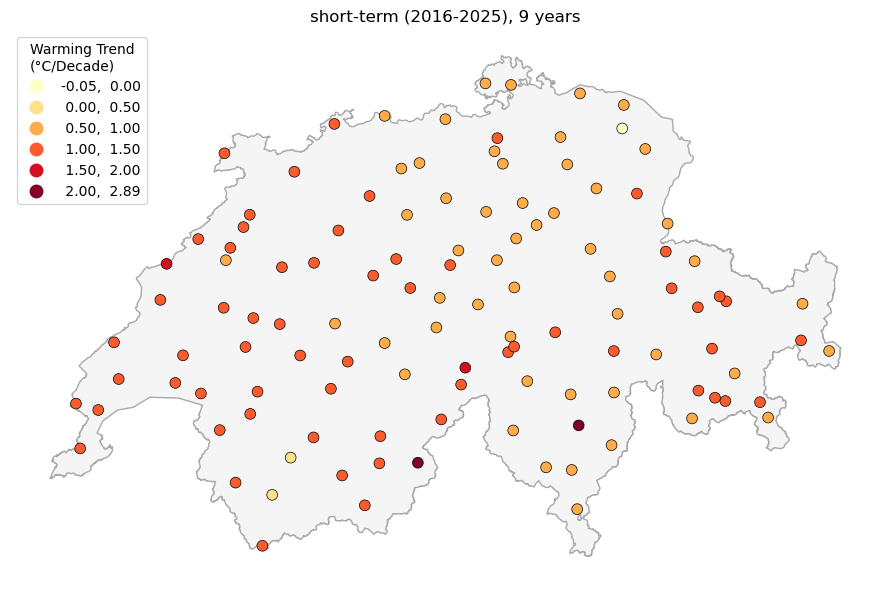

In [13]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Write your code here

# 1. Load the national basemap
base_map = gpd.read_file("swissBoundaries3D_switzerland.gpkg").to_crs(epsg=2056)
ch_mainland = base_map[base_map["name"] == "Schweiz"].copy()

# 2. Define fixed upper bounds for our UserDefined categories
fixed_bins = [0.0, 0.5, 1.0, 1.5, 2.0]

# 3. Configuration Setup
target_column = "trends_10yr"
plot_titles = {
    "trends_all": "long-term (1981-2025), 45 years",
    "trends_30yr": "mid-term (1996-2025), 30 years",
    "trends_10yr": "short-term (2016-2025), 9 years"
}



# 4. Setup the plot canvas
fig, ax = plt.subplots(figsize=(9, 6))

# Draw the basemap
ch_mainland.plot(ax=ax, color="whitesmoke", edgecolor="darkgrey", linewidth=1)

# Plot the classified weather stations dynamically
stations_gdf.plot(
    ax=ax, 
    column=target_column, 
    scheme="UserDefined",                       
    classification_kwds={"bins": fixed_bins},   
    cmap="YlOrRd",                              
    markersize=60, 
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "title": "Warming Trend\n(°C/Decade)", 
        "loc": "upper left",
        "fontsize": 10
    }
)

# 5. Apply the dynamic title and clean up
ax.set_title(plot_titles[target_column])
ax.axis("off")

plt.tight_layout()
plt.show()

---

## Part 5 – Regional Impact (Cantons)

The government doesn't just want to see individual stations; politicians want to know how *their* specific canton is faring. We need to transition from analyzing individual points to aggregating regional polygons.

To do this, we will reuse a spatial loop technique you learned previously: iterating through each canton, asking which weather stations fall `within` its borders, calculating the mean of those stations, and saving the results.

### Tasks

1.  **Load the Regions:** Load `swissBoundaries3D_cantons.gpkg` as `cantons_gdf` and ensure it is in the `EPSG:2056` projection.
2.  **Initialize Columns:** Create three new columns in `cantons_gdf` called `avg_trend_10yr`, `avg_trend_30yr`, and `avg_trend_all`. Fill them all initially with `np.nan`.
3.  **The Spatial Loop:** Write a `for` loop using `.iterrows()` on `cantons_gdf`.
    * Inside the loop, isolate the current canton's geometry.
    * Create a mask to find which stations from `stations_gdf` are `.within()` the canton.
    * If the canton contains stations (`if not stations_inside.empty:`), calculate the `.mean()` for all three trend columns and assign them to the respective new columns in `cantons_gdf` using `.at[idx, "column_name"]`.
4.  **Setup the Configuration:** Define a variable called `target_column` and set it to `"avg_trend_all"`. Then, define `fixed_bins = [0.0, 0.5, 1.0, 2.0, 3.5]` and recreate your `plot_titles` dictionary mapping the new column names to the descriptive titles.
5.  **Visualize the Regional Crisis:** Create a single subplot canvas (`figsize=(10, 6)`). 
    * Plot `cantons_gdf` using your `target_column`.
    * Use `missing_kwds` to color any cantons that didn't have long-term stations in `lightgrey`. 
    * Use the `UserDefined` scheme with your fixed bins and the `YlOrRd` colormap so the polygon map is perfectly comparable to your point maps! Add the dynamic title and explore the different timeframes.

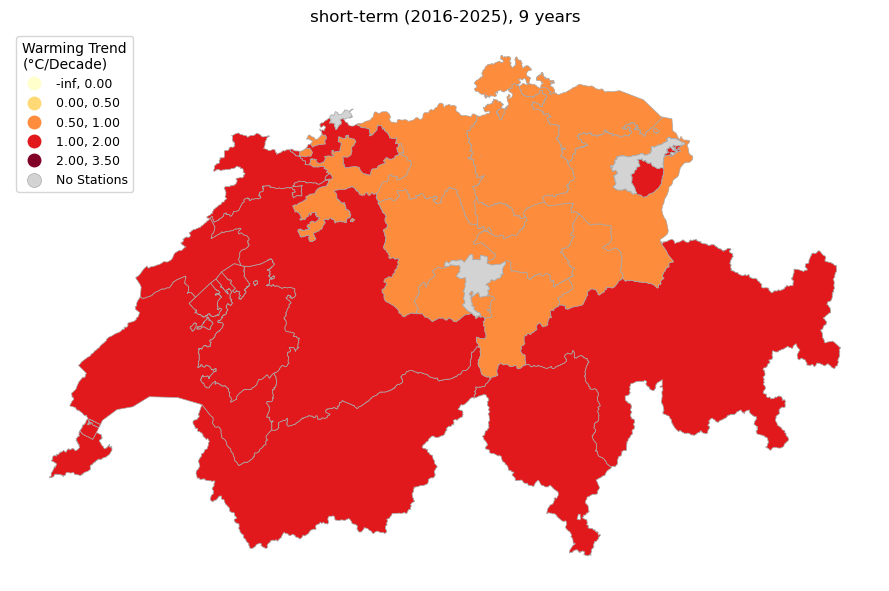

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Write your code here

# 1. Load cantons
cantons_gdf = gpd.read_file("swissBoundaries3D_cantons.gpkg").to_crs(epsg=2056)

# 2. Initialize empty columns for our three metrics
cantons_gdf["avg_trend_10yr"] = np.nan
cantons_gdf["avg_trend_30yr"] = np.nan
cantons_gdf["avg_trend_all"] = np.nan

# 3. The Spatial Loop
for idx, canton in cantons_gdf.iterrows():

    # stations inside canton geometry
    mask = stations_gdf.within(canton.geometry)

    stations_inside = stations_gdf[mask]

    if not stations_inside.empty:

        cantons_gdf.at[idx, "avg_trend_10yr"] = stations_inside["trends_10yr"].mean()
        cantons_gdf.at[idx, "avg_trend_30yr"] = stations_inside["trends_30yr"].mean()
        cantons_gdf.at[idx, "avg_trend_all"] = stations_inside["trends_all"].mean()

# 4. Setup the Configuration
fixed_bins = [0.0, 0.5, 1.0, 2.0, 3.5]
target_column = "avg_trend_10yr"
plot_titles = {
    "avg_trend_all": "long-term (1981-2025), 45 years",
    "avg_trend_30yr": "mid-term (1996-2025), 30 years",
    "avg_trend_10yr": "short-term (2016-2025), 9 years"
}


# 5. Visualize the Regional Crisis dynamically
fig, ax = plt.subplots(figsize=(9, 6))

cantons_gdf.plot(
    ax=ax,
    column=target_column,
    scheme="UserDefined",
    classification_kwds={"bins": fixed_bins},
    cmap="YlOrRd",
    edgecolor="darkgrey",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "title": "Warming Trend\n(°C/Decade)", 
        "loc": "upper left", 
        "fontsize": 9
    },
    missing_kwds={"color": "lightgrey", "label": "No Stations"}
)

ax.set_title(plot_titles[target_column])
ax.axis("off")

plt.tight_layout()
plt.show()

---

## Reflection

Take a step back and review what you have accomplished. You just built a automated data pipeline that ingests live government API data, engineers complex historical climate metrics, and visually aggregates them to the regional level! 

Please answer the following questions briefly:

1. **Interpreting the Data:** Compare your "Short-Term" (10-year) map to the "Long-Term" (45-year) map. Based on the changing color gradients, what can you scientifically conclude about the *pace* of warming in Switzerland? Is the temperature rising at a constant linear rate, or is something else happening?
2. **Refining the Code:** In Part 5, we used a manual Python `for` loop and the `.within()` geometry method to figure out which stations belonged inside which canton. What specific GeoPandas function (which you learned in a previous chapter) is designed to perform this exact spatial intersection and attribute transfer in a single, highly optimized line of code?
3. **Real-World Policy:** Look at the cantons colored "light grey" (Missing Data). If you were a local politician or environmental planner in one of these regions, what is the danger of relying purely on this specific map for your climate adaptation strategy? What physical infrastructure investment would you likely argue for first?